# Лабораторная работа 1 — Heart Disease (вариант 17)

**Цель:** настроить воспроизводимый проект (Git + DVC) и построить конвейер с `Pipeline`, `ColumnTransformer` и кастомным трансформером `age²`.

**Датасет:** Heart Disease (UCI / Cleveland)  
**Задача:** классификация (`target` — наличие болезни)  
**Кастомный трансформер:** добавляет признак «возраст в квадрате»


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.features.transformers import AgeSquaredTransformer

sns.set_theme(style="whitegrid")
print("ROOT =", ROOT)

ROOT = /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml


## 1. Загрузка данных

In [2]:
raw_path = ROOT / "data" / "raw" / "heart_disease.csv"
df = pd.read_csv(raw_path)
print(df.shape)
display(df.head())
print("Пропуски:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nБаланс классов:")
print(df["target"].value_counts(normalize=True).round(3))

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.0,233.0,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130.0,250.0,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130.0,204.0,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120.0,236.0,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120.0,354.0,0,1,163,1,0.6,2,0,2,1


Пропуски:
trestbps    30
chol        30
dtype: int64

Баланс классов:
target
1    0.545
0    0.455
Name: proportion, dtype: float64


## 2. Train / test split (80/20, `random_state=42`)

In [3]:
TARGET = "target"
NUMERIC = ["age", "trestbps", "chol", "thalach", "oldpeak", "age_squared"]
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train={len(X_train)}, test={len(X_test)}")

train=242, test=61


## 3. Пайплайн

1. `AgeSquaredTransformer` — добавляет `age_squared = age²`
2. `ColumnTransformer`:
   - числовые: медиана + `StandardScaler`
   - категориальные: мода + `OneHotEncoder(handle_unknown='ignore')`
3. `LogisticRegression` (+ опциональный `GridSearchCV` по `C`)


In [4]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC),
    ("cat", categorical_pipe, CATEGORICAL),
])

pipe = Pipeline([
    ("age_squared", AgeSquaredTransformer(age_col="age", out_col="age_squared")),
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

search = GridSearchCV(
    pipe,
    param_grid={"model__C": [0.1, 1.0, 10.0]},
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
search.fit(X_train, y_train)
print("best_params:", search.best_params_)
print(f"CV ROC-AUC: {search.best_score_:.4f}")
best = search.best_estimator_

best_params: {'model__C': 0.1}
CV ROC-AUC: 0.9187


## 4. Оценка на тесте

Accuracy: 0.8689
ROC-AUC:  0.9037
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        28
           1       0.84      0.94      0.89        33

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.87        61
weighted avg       0.87      0.87      0.87        61



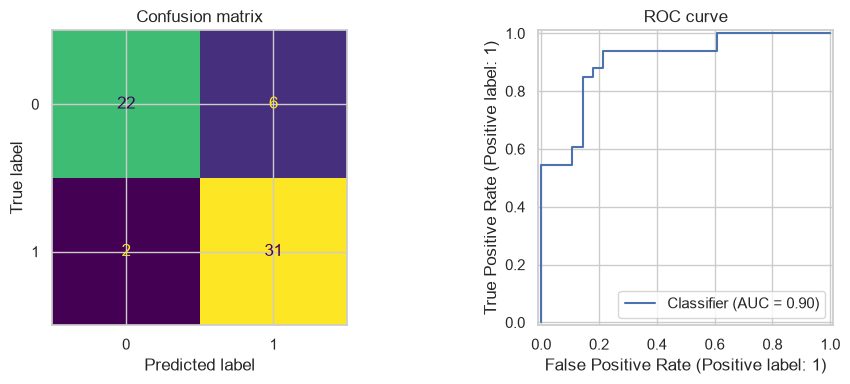

In [5]:
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC curve")
plt.tight_layout()
plt.show()

## 5. Проверка кастомного трансформера

In [6]:
demo = AgeSquaredTransformer().fit_transform(X_train.head())
display(demo[["age", "age_squared"]].head())
assert np.allclose(demo["age_squared"], demo["age"] ** 2)
print("age_squared = age² — OK")

,age,age_squared
19,69,4761.0
247,66,4356.0
289,55,3025.0
288,57,3249.0
60,71,5041.0


age_squared = age² — OK


## 6. Сохранение модели

In [7]:
model_path = ROOT / "models" / "heart_disease_pipeline.joblib"
joblib.dump(best, model_path)
print("saved:", model_path)

saved: /Users/zesmolovaya/Desktop/Prpdv-m/heart-disease-ml/models/heart_disease_pipeline.joblib
